In [1]:
from runtime_support import (
    setup_client_from_env,
    build_fleet_object,
    )

import asyncio

from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi

with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

from core_helpers import (load_initial_fleet_state,
                          init_world_state,
                          load_initial_waypoint_state,
                          get_wps_by_trait,
                          all_wp_visitor,
                          api_navigate_ship,
                          api_get_ship_nav,
                          plot_route_svg,
                          patrol_markets,
                          )


#-------- write fleet activity and fleet specifications to db -------------
state = await load_initial_fleet_state(fleet_api)

#-------- write waypoint reference data and traits specifications to db and local objects -------------
wp_refs, wp_traits = await load_initial_waypoint_state(agents_api, systems_api)
print(f"Persisted {len(wp_refs)} waypoint refs and {len(wp_traits)} traits.")

# --------- create locally persisting objects for fleet and world states -------------------
ships_activity_obj = await build_fleet_object(fleet_api)
world_state = await init_world_state(fleet_api, agents_api, systems_api)

# --------- define ship roles -----------

# Extract symbol for a given role
def get_symbol_by_role(ships_dict, role):
    for ship in ships_dict.values():
        if ship.role == role:
            return ship.symbol
    return None

# manually assign ship names by role
command_ship = get_symbol_by_role(state.specs, "COMMAND")
satellite = get_symbol_by_role(state.specs, "SATELLITE")


# ---------- get market waypoints from world state ----------
# all traits of every waypoint
traits_list = world_state.traits.by_wp
# selecting MARKETPLACE trait-bearing waypoints only
markets_df = await get_wps_by_trait(traits_list, "MARKETPLACE")

shipyards_df = await get_wps_by_trait(traits_list, "SHIPYARD")
print(shipyards_df)


Persisted 84 waypoint refs and 237 traits.
[BOOT] Adapted 2 ships into fleet_object
      waypoint    x    y    distance
0   X1-BP71-A2   21  -11   23.706539
1  X1-BP71-H49   34   28   44.045431
2  X1-BP71-C39 -102  117  155.219200


X1-BP71-A1
    visit_idx      waypoint    x    y  leg_distance  cumulative_distance
0           0    X1-BP71-A2   21  -11         0.000                0.000
1           1    X1-BP71-A1   21  -11         0.000                0.000
2           2    X1-BP71-A4   21  -11         0.000                0.000
3           3    X1-BP71-A3   21  -11         0.000                0.000
4           4  X1-BP71-EF5D   27   11        22.804               22.804
5           5   X1-BP71-H49   34   28        18.385               41.188
6           6   X1-BP71-H50   34   28         0.000               41.188
7           7   X1-BP71-H48   34   28         0.000               41.188
8           8   X1-BP71-H51   34   28         0.000               41.188
9           9   X1-BP71-D42    5   86        64.846              106.034
10         10   X1-BP71-D41    5   86         0.000              106.034
11         11   X1-BP71-C39 -102  117       111.400              217.434
12         12   X1-BP71-C40  -76   87   

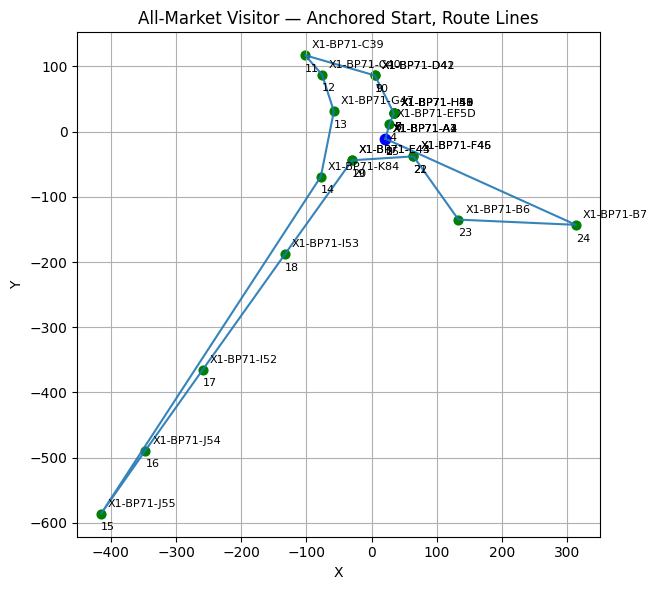

In [2]:
# from selected ships' starting waypoint, draw a route that will visit all market waypoints

nav_resp = await api_get_ship_nav(fleet_api, command_ship)
start = nav_resp.waypoint_symbol

print(nav_resp.waypoint_symbol)
if __name__ == "__main__":
    
    start = shipyards_df.iloc[0,0]

    route = all_wp_visitor(
        markets_df,
        start_waypoint=start,
        return_to_start=True,   # set True to draw a loop back to start
        improve_2opt=True,
        fix_start_anchor=True,   # keep chosen start as first
    )

    print(route)
    print("Total travel distance:", route["cumulative_distance"].iloc[-1])

    plot_route_svg(
        markets_df=markets_df,
        route_df=route,
        start_waypoint=start,
        svg_path="markets_route.svg",
    )

from core_helpers import build_nodes_from_traits_dict

wps = world_state.traits.by_wp
nodes = build_nodes_from_traits_dict(wps)


# ---------- run ----------
async def main():
    patroller = asyncio.create_task(patrol_markets(fleet_api, command_ship, route, nodes))
    #patroller2 = asyncio.create_task(patrol_markets(command_ship, route))
    await asyncio.gather(patroller)

In [ ]:
# await api_navigate_ship(fleet_api, ship_symbol, wp)
await main()

Waypoints to patrol: ['X1-BP71-A2', 'X1-BP71-A1', 'X1-BP71-A4', 'X1-BP71-A3', 'X1-BP71-EF5D', 'X1-BP71-H49', 'X1-BP71-H50', 'X1-BP71-H48', 'X1-BP71-H51', 'X1-BP71-D42', 'X1-BP71-D41', 'X1-BP71-C39', 'X1-BP71-C40', 'X1-BP71-G47', 'X1-BP71-K84', 'X1-BP71-J55', 'X1-BP71-J54', 'X1-BP71-I52', 'X1-BP71-I53', 'X1-BP71-E44', 'X1-BP71-E43', 'X1-BP71-F46', 'X1-BP71-F45', 'X1-BP71-B6', 'X1-BP71-B7']
Leg distances aligned: [0, 0, 0, 0, 22, 18, 0, 0, 0, 64, 0, 111, 39, 58, 101, 617, 118, 152, 217, 177, 0, 94, 0, 119, 180]
[PATROL] BANGO-1 looping through 25 markets. Starting at X1-BP71-A2
[PATROL] -> Navigating to X1-BP71-A2 (#1/25), leg ~ 0.0
starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Refuelling now...
Not in orbit, going into orbit now...
Prep complete
BANGO-1  has taken off and is in transit
[BOOT] Adapted 2 ships into fleet_object
Seconds until arrival: 14.773938
Arrived and ready
[MARKET] Capturing X1-BP71-A2 …
[PATROL] -> Navigating to X1-BP

In [ ]:
import asyncio
from core_helpers import build_nodes_from_traits_dict
from refuel_routing import plan_route_and_refuel
from typing import Tuple

async def long_dist_travel(cur_wp, dest_wp, trav_dist, max_trav_dist):

    with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

    world_state =  await init_world_state(fleet_api, agents_api, systems_api)
    wps = world_state.traits.by_wp
    nodes = build_nodes_from_traits_dict(wps)
    route_plan = plan_route_and_refuel(nodes, cur_wp, dest_wp, trav_dist, 1, 1000, max_trav_dist, 100, 0, 10, 0)
    plan_route_and_refuel()
    refuel_route = route_plan["path"]
    
    return(refuel_route)

#world_state.traits.by_wp


In [ ]:
# test whether a waypoint is out of reach for a ships' fuel tank

from runtime_support import (
    setup_client_from_env,
    build_fleet_object,
    )

import asyncio

from openapi_client.api.fleet_api import FleetApi
from openapi_client.api.agents_api import AgentsApi
from openapi_client.api.systems_api import SystemsApi

with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        agents_api = AgentsApi(client)
        systems_api = SystemsApi(client)

from core_helpers import (load_initial_fleet_state,
                          init_world_state,
                          load_initial_waypoint_state,
                          get_wps_by_trait,
                          all_market_visitor,
                          api_get_ship_nav,
                          plot_route_svg,
                          patrol_markets,
                          api_navigate_ship
                          )


async def travel_checker(ship_symbol: str, waypoint_symbol: str):

    with setup_client_from_env() as client:
        fleet_api = FleetApi(client)
        systems_api = SystemsApi(client)
        agents_api = AgentsApi(client)

    world_state =  await init_world_state(fleet_api, agents_api, systems_api)

    ships = await build_fleet_object(fleet_api)
    trav_dist = ships.by_symbol[ship_symbol].fuel_current
    max_trav_dist = ships.by_symbol[ship_symbol].fuel_capacity
    cur_wp = ships.by_symbol[ship_symbol].current_waypoint

    cur_x = world_state.waypoints.by_symbol[cur_wp].x
    cur_y = world_state.waypoints.by_symbol[cur_wp].y

    dest = waypoint_symbol

    dest_x = world_state.waypoints.by_symbol[dest].x
    dest_y = world_state.waypoints.by_symbol[dest].y

    x_len = cur_x - dest_x

    y_len = cur_y - dest_y

    import math

    hypo = math.hypot(x_len, y_len)
    print("Distance between coords: ", hypo)

    if hypo > trav_dist:
        # apply routefinder to calculate best route with refuels between distant points
        print("Destination too far, initiating hops")
        route = await long_dist_travel(cur_wp, dest, trav_dist, max_trav_dist)

        for rt in route:
            await api_navigate_ship(fleet_api, ship_symbol, rt)

        return
    else:
         await api_navigate_ship(fleet_api, ship_symbol, waypoint_symbol)


#world_state.waypoints.by_symbol


In [ ]:
#await api_get_ship_nav(fleet_api, command_ship)

ShipNav(system_symbol='X1-CX40', waypoint_symbol='X1-CX40-B10', route=ShipNavRoute(destination=ShipNavRouteWaypoint(symbol='X1-CX40-B10', type=<WaypointType.ASTEROID: 'ASTEROID'>, system_symbol='X1-CX40', x=25, y=374), origin=ShipNavRouteWaypoint(symbol='X1-CX40-A4', type=<WaypointType.ORBITAL_STATION: 'ORBITAL_STATION'>, system_symbol='X1-CX40', x=8, y=26), departure_time=datetime.datetime(2025, 9, 18, 14, 58, 10, 513000, tzinfo=TzInfo(UTC)), arrival=datetime.datetime(2025, 9, 18, 15, 2, 27, 513000, tzinfo=TzInfo(UTC))), status=<ShipNavStatus.IN_ORBIT: 'IN_ORBIT'>, flight_mode=<ShipNavFlightMode.CRUISE: 'CRUISE'>)

In [ ]:
#long_dest = 'X1-CX40-J74'
#await travel_checker(command_ship, long_dest)

[BOOT] Adapted 2 ships into fleet_object
Distance between coords:  387.5061289837878
Destination too far, initiating hops


NetworkXNoPath: No path to X1-CX40-J74.

['X1-XG6-A2', 'X1-XG6-H57', 'X1-XG6-C46']
[PATROL] DDDD-2 looping through 3 markets.
[PATROL] -> Navigating to X1-XG6-A2 (#1/3)
starting navigation...
[BOOT] Adapted 2 ships into fleet_object
Not at destination, continuing
Prep complete
DDDD-2  has taken off and is in transit
[BOOT] Adapted 2 ships into fleet_object
Seconds until arrival: 185.937644
